In [2]:
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import os
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
base_dir   = '/kaggle/input/datasets/raphalperon/data-scap/total_segmentator_scap_hum/patients4/patients4'
output_dir = '/kaggle/working/'


In [3]:

#Étape 1 : Pré-traitement et extraction de patches
#Cette étape convertit les volumes 3D en petits patches pour l'entraînement du modèle.
patches_ct = [] #Liste pour stocker les cubes de scanner (données d'entrée)
patches_masque = [] #Liste pour stocker les cubes de segmentation (vérité terrain)
patients_valides  = 0 #Compteur de patients traités avec succès

for dossier in sorted(os.listdir(base_dir)):
    #Exclusion du patient s0224 réservé exclusivement à l'inférence
    if dossier == 's0224': 
        continue 
    dossier_path = os.path.join(base_dir, dossier)
    if not os.path.isdir(dossier_path):
        continue
        
    ct_path = os.path.join(dossier_path, 'ct.nii')
    if not os.path.exists(ct_path):
        continue
        
    #Chargement du scanner et conversion en float32 pour le calcul
    ct = nib.load(ct_path).get_fdata().astype(np.float32)

    #Normalisation : on se focalise sur les tissus mous et l'os (-200 à 1800 HU)
    ct = np.clip(ct, -200, 1800)
    ct = (ct - (-200)) / (1800 - (-200))

    #Fusion des masques gauche et droit pour obtenir une segmentation globale
    masque_global = np.zeros(ct.shape, dtype=np.uint8)
    for nom in ['scapula_left', 'scapula_right']:
        masque_path = os.path.join(dossier_path, 'segmentations', f'{nom}.nii')
        if os.path.exists(masque_path):
            masque_local = (nib.load(masque_path).get_fdata() > 0).astype(np.uint8)

            #Correction de l'orientation si nécessaire (différence entre CT (z,y,x) et NIfTI (x,y,z))
            if masque_local.shape != ct.shape:
                masque_local = np.transpose(masque_local, (2, 1, 0))
            if masque_local.shape == ct.shape:
                masque_global = np.clip(masque_global + masque_local, 0, 1)

    #On ignore les volumes dont la segmentation est trop faible (< 20k voxels)
    if masque_global.sum() < 20000:
        del ct, masque_global
        continue

    taille, pas = 64, 32
    z_max, y_max, x_max = ct.shape
    n = 0 #Compteur de patches pour ce patient précis
    #Découpage en patches de 64x64x64 avec un chevauchement de 50% (pas de 32)
    for z in range(0, z_max - taille + 1, pas):
        for y in range(0, y_max - taille + 1, pas):
            for x in range(0, x_max - taille + 1, pas):
                patch_masque = masque_global[z:z+taille, y:y+taille, x:x+taille]
                patch_ct= ct[z:z+taille,     y:y+taille, x:x+taille]
                #On garde le patch s'il contient de la scapula (masque) 
                #OU s'il contient de l'os dense (HU > 800) pour apprendre au modèle à ne pas confondre les structures.
                if patch_masque.sum() > 50 or patch_ct.max() > 0.5:
                    #Stockage en float16 pour optimiser l'occupation de la RAM
                    patches_ct.append(patch_ct.astype(np.float16)) 
                    patches_masque.append(patch_masque.astype(np.uint8))
                    n += 1

    patients_valides += 1
    print(f"{dossier} → {n} patches | total : {len(patches_ct)}")
    del ct, masque_global #Libération de la mémoire

print(f"\n {patients_valides} patients | {len(patches_ct)} patches")

#Sauvegarde du dataset compressé pour l'entraînement ultérieur
np.savez_compressed(
    output_dir + 'patches.npz',
    patches_ct_array = np.array(patches_ct, dtype=np.float16),
    patches_masque_array = np.array(patches_masque, dtype=np.uint8)
)
print(f"Sauvegardé | {os.path.getsize(output_dir+'patches.npz')/1e9:.1f} GB")

s0011 → 363 patches | total : 363
s0019 → 224 patches | total : 587
s0021 → 78 patches | total : 665
s0024 → 432 patches | total : 1097
s0029 → 354 patches | total : 1451
s0035 → 153 patches | total : 1604
s0040 → 413 patches | total : 2017
s0046 → 154 patches | total : 2171
s0049 → 272 patches | total : 2443
s0050 → 211 patches | total : 2654
s0061 → 117 patches | total : 2771
s0063 → 74 patches | total : 2845
s0065 → 336 patches | total : 3181
s0076 → 542 patches | total : 3723
s0079 → 122 patches | total : 3845
s0080 → 295 patches | total : 4140
s0086 → 274 patches | total : 4414
s0091 → 400 patches | total : 4814
s0102 → 184 patches | total : 4998
s0111 → 144 patches | total : 5142
s0115 → 416 patches | total : 5558
s0123 → 142 patches | total : 5700
s0124 → 238 patches | total : 5938
s0145 → 205 patches | total : 6143
s0146 → 100 patches | total : 6243
s0152 → 157 patches | total : 6400
s0162 → 174 patches | total : 6574
s0163 → 357 patches | total : 6931
s0175 → 107 patches | tot

In [3]:
#Étape 2 : Chargement du Dataset
#On recharge les patches précalculés pour l'entraînement du modèle.
#Note : On conserve le typage float16/uint8 pour limiter l'empreinte mémoire.
data    = np.load(output_dir + 'patches.npz')

# Chargement des images (CT) et des masques de segmentation
patches = data['patches_ct_array'].astype(np.float16)
masques = data['patches_masque_array'].astype(np.uint8)
print(f"Patches chargés : {patches.shape}")
print(f"Taille RAM : {patches.nbytes/1e9:.1f} GB")

Patches chargés : (8803, 64, 64, 64)
Taille RAM : 4.6 GB


Device : cuda
Utilisation de 2 GPUs
Epoch 01/25 | Train : 1.3384 | Val : 1.1857
  Meilleur modèle sauvegardé ! (val=1.1857)
Epoch 02/25 | Train : 1.0914 | Val : 1.1467
  Meilleur modèle sauvegardé ! (val=1.1467)
Epoch 03/25 | Train : 0.9682 | Val : 1.1775
  Pas d'amélioration (1/5)
Epoch 04/25 | Train : 0.7569 | Val : 0.7616
  Meilleur modèle sauvegardé ! (val=0.7616)
Epoch 05/25 | Train : 0.5953 | Val : 0.8029
  Pas d'amélioration (1/5)
Epoch 06/25 | Train : 0.5138 | Val : 0.4307
  Meilleur modèle sauvegardé ! (val=0.4307)
Epoch 07/25 | Train : 0.4866 | Val : 0.4091
  Meilleur modèle sauvegardé ! (val=0.4091)
Epoch 08/25 | Train : 0.3930 | Val : 0.3191
  Meilleur modèle sauvegardé ! (val=0.3191)
Epoch 09/25 | Train : 0.3611 | Val : 0.3508
  Pas d'amélioration (1/5)
Epoch 10/25 | Train : 0.3225 | Val : 0.7818
  Pas d'amélioration (2/5)
Epoch 11/25 | Train : 0.2842 | Val : 0.2699
  Meilleur modèle sauvegardé ! (val=0.2699)
Epoch 12/25 | Train : 0.2871 | Val : 0.3014
  Pas d'amélioration

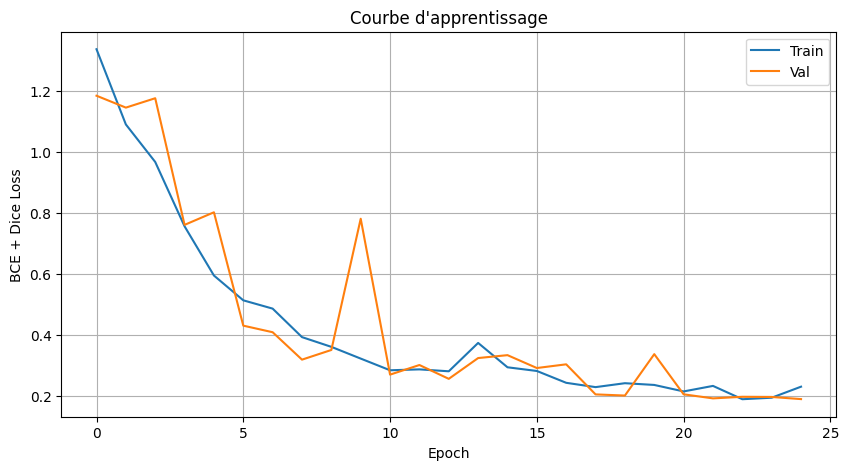


  Meilleur val loss : 0.1895 — Dice : 0.905


In [6]:
#Étape 3 : Entraînement du modèle UNet 3D

import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import os
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import gc

base_dir   = '/kaggle/input/datasets/raphalperon/data-scap/total_segmentator_scap_hum/patients4/patients4'
output_dir = '/kaggle/working/'

#bloc double convolution classique pour l'extraction de caractéristiques spatiales.
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.encodeur = nn.ModuleList()
        self.pool     = nn.MaxPool3d(kernel_size=2, stride=2)
        #Partie descendante (Encoder)
        for feature in features:
            self.encodeur.append(DoubleConv(in_channels, feature))
            in_channels = feature
        self.fond = DoubleConv(features[-1], features[-1] * 2)
        self.decodeur_up   = nn.ModuleList()
        self.decodeur_conv = nn.ModuleList()

        # Partie ascendante (Decoder)
        for feature in reversed(features):
            self.decodeur_up.append(
                nn.ConvTranspose3d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decodeur_conv.append(DoubleConv(feature * 2, feature))
        self.sortie  = nn.Conv3d(features[0], out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        skip_connections = []
        for couche in self.encodeur:
            x = couche(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.fond(x)
        skip_connections = skip_connections[::-1]
        for i in range(len(self.decodeur_up)):
            x    = self.decodeur_up[i](x)
            skip = skip_connections[i]
            #Ajustement de la taille si nécessaire pour la concaténation (skip connections)
            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.decodeur_conv[i](x)
        return self.sigmoid(self.sortie(x))

class ScapulaDataset(Dataset):
    def __init__(self, patches, masques):
        self.patches = patches
        self.masques = masques

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        #Conversion en float32 pour PyTorch
        patch  = self.patches[idx].astype(np.float32).copy()
        masque = self.masques[idx].astype(np.float32).copy()

        for axe in [0, 1, 2]:
            if np.random.rand() > 0.5:
                #Data Augmentation : Flips aléatoires sur les 3 axes
                patch  = np.flip(patch,  axe).copy()
                masque = np.flip(masque, axe).copy()

        #Ajout d'un bruit gaussien léger pour la robustesse
        patch += np.random.normal(0, 0.02, patch.shape)
        patch  = np.clip(patch, 0, 1)

        return (torch.tensor(patch,  dtype=torch.float32).unsqueeze(0),
                torch.tensor(masque, dtype=torch.float32).unsqueeze(0))

#Loss fonction qui combine Dice Loss (pour la forme) et BCE pondéré (pour gérer le déséquilibre fond/scapula).
def bce_dice_loss(prediction, cible, epsilon=1e-6):
    p = prediction.view(-1)
    c = cible.view(-1)
    #Dice Loss
    intersection = (p * c).sum()
    dice = 1 - (2 * intersection + epsilon) / (p.sum() + c.sum() + epsilon)
    #Weighted BCE : Un voxel scapula est 20x plus important qu'un voxel de fond
    bce  = torch.nn.functional.binary_cross_entropy(
        prediction, cible, weight=(cible * 19 + 1) 
    )
    return dice + bce

#Configuration de l'entraînement

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

dataset    = ScapulaDataset(patches, masques)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4)

model      = UNet3D().to(device)
if torch.cuda.device_count() > 1:
    print(f"Utilisation de {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
optimiseur = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiseur, mode='min', patience=4, factor=0.5)

#Boucle d'entraînement
nb_epochs                = 25
patience                 = 5
train_losses             = []
val_losses               = []
meilleur_val             = float('inf')
epochs_sans_amelioration = 0

for epoch in range(nb_epochs):
    model.train()
    train_loss = 0
    for patch, masque in train_loader:
        patch, masque = patch.to(device), masque.to(device)
        prediction    = model(patch)
        loss          = bce_dice_loss(prediction, masque)
        optimiseur.zero_grad()
        loss.backward()
        optimiseur.step()
        train_loss += loss.item()
        #Nettoyage mémoire explicite pour le GPU
        del patch, masque, prediction, loss
        torch.cuda.empty_cache()
        
    train_loss /= len(train_loader)
    gc.collect()
    torch.cuda.empty_cache()
    
    #Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for patch, masque in val_loader:
            patch, masque = patch.to(device), masque.to(device)
            val_loss     += bce_dice_loss(model(patch), masque).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d}/{nb_epochs} | Train : {train_loss:.4f} | Val : {val_loss:.4f}")

    if val_loss < meilleur_val:
        meilleur_val             = val_loss
        epochs_sans_amelioration = 0
        torch.save(model.state_dict(), '/kaggle/working/meilleur_modele_scapula.pth')
        print(f"  Meilleur modèle sauvegardé ! (val={meilleur_val:.4f})")
    else:
        epochs_sans_amelioration += 1
        print(f"  Pas d'amélioration ({epochs_sans_amelioration}/{patience})")
        if epochs_sans_amelioration >= patience:
            print(f"  Early stopping à l'epoch {epoch+1}")
            break

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch')
plt.ylabel('BCE + Dice Loss')
plt.title("Courbe d'apprentissage")
plt.legend()
plt.grid(True)
plt.savefig('/kaggle/working/courbe_apprentissage.png')
plt.show()
print(f"\n  Meilleur val loss : {meilleur_val:.4f} — Dice : {1 - meilleur_val/2:.3f}")